In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

from gsmo.hist_features_uni import extract_embeddings
from gsmo.utils import *
from gsmo import GSMO, GSMOConfig
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import random

seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")


CUDA is available. GPU: NVIDIA GeForce RTX 3090


In [3]:
import os
os.chdir('data/spatial-CITE-seq/Human_skin')

In [4]:
rna = pd.read_csv("GSM6578065_humanskin_RNA.tsv.gz", sep='\t', index_col=0)
protein = pd.read_csv("GSM6578074_humanskin_protein.tsv.gz", sep='\t', index_col=0)
print(rna.shape, protein.shape)
print(rna.columns[:5])


(1691, 15486) (1691, 283)
Index(['MIR1302.11', 'RP11.34P13.7', 'AL627309.1', 'AP006222.2',
       'RP4.669L17.10'],
      dtype='object')


In [5]:
img = Image.open("skin.jpg")
img = img.convert("RGB")
img_np = np.array(img)
print(img_np.shape)  # (H, W, 3)


(2700, 2704, 3)


count     1691.000000
mean       815.122413
std       1594.854313
min         13.000000
25%        110.000000
50%        205.000000
75%        613.000000
max      14821.000000
dtype: float64


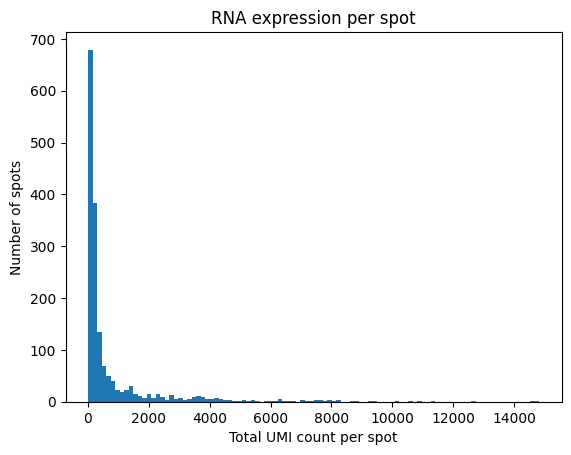

In [6]:
rna_sum = rna.sum(axis=1)
print(rna_sum.describe())
import matplotlib.pyplot as plt

plt.hist(rna_sum, bins=100)
plt.xlabel("Total UMI count per spot")
plt.ylabel("Number of spots")
plt.title("RNA expression per spot")
plt.show()



In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np


def extract_coords_from_index(index):
    coords = [i.split('x') for i in index]
    coords = np.array(coords, dtype=float)
    return coords

coords = extract_coords_from_index(rna.index)

def normalize_coords_adjustable(coords, image_shape, scale_factors=(1.0, 1.0), shift=(0, 0)):
    x_min, y_min = coords.min(axis=0)
    x_max, y_max = coords.max(axis=0)
    coords_norm = (coords - [x_min, y_min]) / ([x_max - x_min, y_max - y_min])
    
    coords_norm[:, 0] = coords_norm[:, 0] * scale_factors[0] + (1 - scale_factors[0]) / 2
    coords_norm[:, 1] = coords_norm[:, 1] * scale_factors[1] + (1 - scale_factors[1]) / 2
    
    coords_img = coords_norm * [image_shape[1], image_shape[0]]
    coords_img[:, 0] += shift[0]
    coords_img[:, 1] += shift[1]
    
    return coords_img.astype(int)



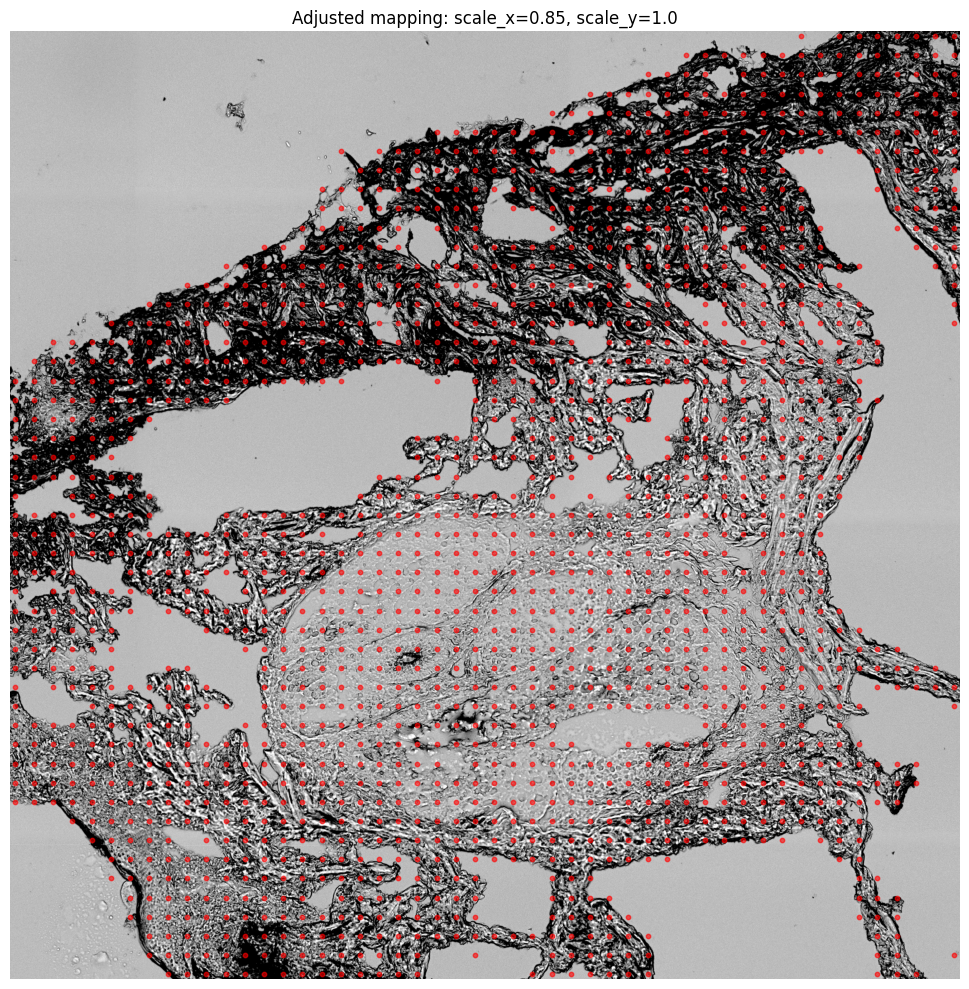

In [ ]:
coords_img_adj = normalize_coords_adjustable(
    coords,
    img_np.shape,
    scale_factors=(0.99, 0.99),  
    shift=(0, 0)
)

plt.figure(figsize=(10, 10))
plt.imshow(img_np)
plt.scatter(coords_img_adj[:, 0], coords_img_adj[:, 1], s=10, c='red', alpha=0.6)
plt.title("Adjusted mapping: scale_x=0.85, scale_y=1.0")
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.preprocessing import StandardScaler


common_index = rna.index.intersection(protein.index)
rna = rna.loc[common_index]
protein = protein.loc[common_index]

def extract_coords_from_index(index):
    coords = [i.split('x') for i in index]
    coords = np.array(coords, dtype=float)
    return coords

coords = extract_coords_from_index(rna.index)

rna_norm = rna.div(rna.sum(axis=1), axis=0) * 1e6
rna_log = np.log1p(rna_norm)

gene_vars = rna_log.var(axis=0)
top_genes = gene_vars.sort_values(ascending=False).index[:3000]
rna_selected = rna_log[top_genes]

protein_log = np.log1p(protein)

protein_scaled = pd.DataFrame(StandardScaler().fit_transform(protein_log), index=protein_log.index, columns=protein_log.columns)


print("Multimodal inputs are ready!")


✅ 多模态输入准备完毕！


In [10]:
print(rna_selected.shape)
print(protein_scaled.shape)
print(coords.shape)

(1691, 3000)
(1691, 283)
(1691, 2)


In [ ]:
#if using a subset of modality-specific terms, the "ind_views" parameter should be a list with values entries to the indices of the modalities to be included, e.g.,  ind_views=[0,2] if including RNA and image features
#if using a subset of interaction terms, the "combs" parameter should be a list of tuples with entries to the indices of the modalities for each interaction, e.g. combs = [(0,1),(0,2)] if including the RNA-protein and RNA-image interaction terms
features_dict = {
        'rna': rna_selected,        # RNA 
        'protein': protein_scaled
    }


initial_weights = [1.0, 1.0]  

cfg = GSMOConfig

model = GSMO(features_dict, spatial_coords=coords, device=device, cfg=cfg,
            trainable_weights=True, initial_weights=initial_weights)

model.load_state_dict(torch.load("best_model.pth"))

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


<All keys matched successfully>

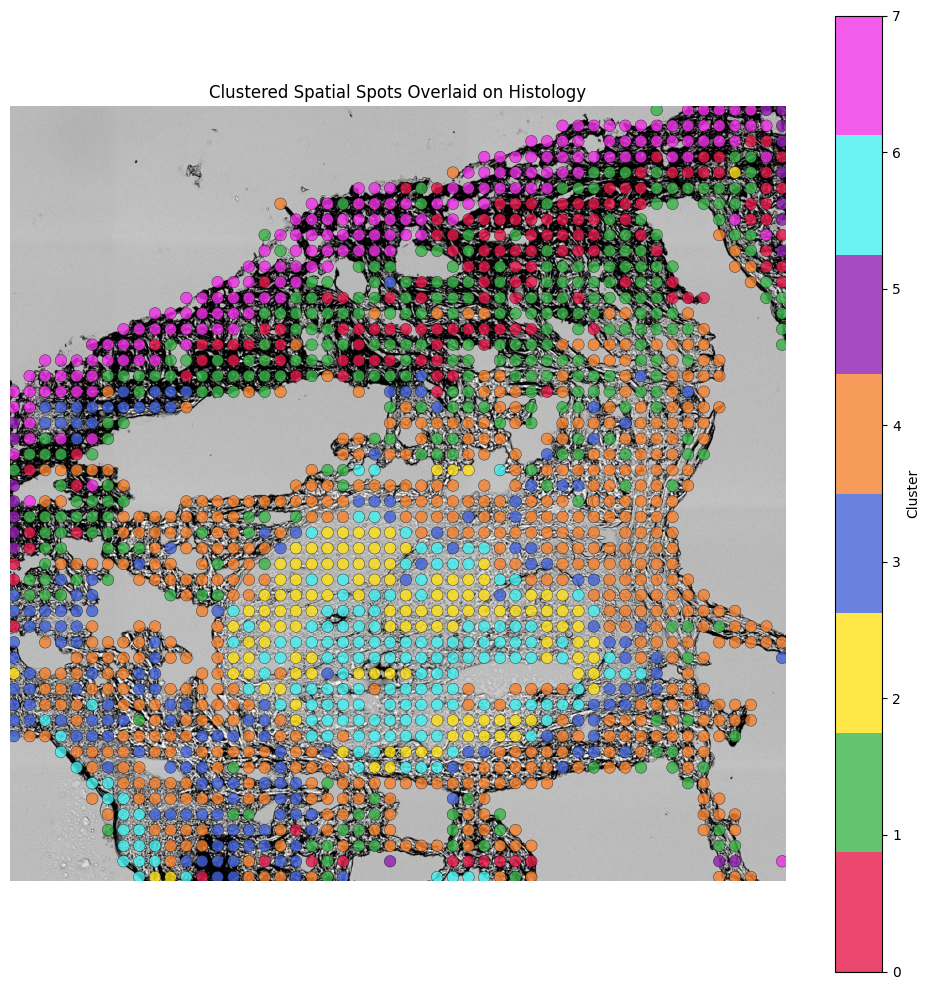

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
import numpy as np
from PIL import Image


coords_img = normalize_coords_adjustable(coords, np.array(img.convert("RGB")).shape, scale_factors=(0.99, 0.99), shift=(0, 0))
clusters = model.cluster_kmeans(n_clusters=8)

plot_color = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', 
              '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#ffd8b1', '#800000', '#aaffc3', 
              '#808000', '#000075', '#000000', '#808080', '#ffffff', '#fffac8', '#D1D1D1']

img = Image.open("skin.jpg").convert("RGB")
img_np = np.array(img)

assert coords_img.shape[0] == len(clusters), "坐标和聚类结果长度不一致"

num_clusters = len(np.unique(clusters))
if num_clusters > len(plot_color):
    raise ValueError(f"聚类数目 {num_clusters} 超过调色板颜色数 {len(plot_color)}")

cmap = ListedColormap(plot_color[:num_clusters])

plt.figure(figsize=(10, 10))
plt.imshow(img_np)
scatter = plt.scatter(coords_img[:, 0], coords_img[:, 1], c=clusters, cmap=cmap, s=70, alpha=0.8, edgecolors='k', linewidths=0.3)
plt.colorbar(scatter, label="Cluster")
plt.title("Clustered Spatial Spots Overlaid on Histology")
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import pairwise_distances
import numpy as np
from tqdm import tqdm

def compute_jaccard_similarity(Z_m, Z_e, k=50):

    dist_m = pairwise_distances(Z_m)
    dist_e = pairwise_distances(Z_e)
    
    n = Z_m.shape[0]
    jaccard_scores = []

    for i in tqdm(range(n), desc="Calculating Jaccard similarities"):
        neighbors_m = set(np.argsort(dist_m[i])[1:k+1])  # exclude self
        neighbors_e = set(np.argsort(dist_e[i])[1:k+1])
        intersection = len(neighbors_m & neighbors_e)
        union = len(neighbors_m | neighbors_e)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_scores.append(jaccard)

    return np.array(jaccard_scores), np.mean(jaccard_scores)


import squidpy as sq
import scanpy as sc
import pandas as pd
import numpy as np

def compute_morans_I(labels, spatial_coords, label_name="cluster_label"):
    adata = sc.AnnData(X=np.zeros((len(labels), 1)))  # dummy
    adata.obs[label_name] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    sq.gr.spatial_autocorr(adata, mode="moran", genes=label_name, attr="obs")

    moran_result = adata.uns["moranI"].loc[label_name, "I"]
    return moran_result




/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [ ]:

fused_embeddings = model.get_embeddings()


# 1. Jaccard
jaccard_all, jaccard_mean = compute_jaccard_similarity(rna_selected, fused_embeddings, k=50)
print(f"Mean Jaccard RNA Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(protein_scaled, fused_embeddings, k=50)
print(f"Mean Jaccard protein Similarity: {jaccard_mean:.4f}")


cluster_labels = model.cluster_kmeans(n_clusters=8)
morans_I = compute_morans_I(cluster_labels, coords)
print(f"Moran's I score: {morans_I:.4f}")



Calculating Jaccard similarities: 100%|██████████| 1691/1691 [00:00<00:00, 7026.92it/s]


Mean Jaccard RNA Similarity: 0.0389


Calculating Jaccard similarities: 100%|██████████| 1691/1691 [00:00<00:00, 7837.52it/s]


Mean Jaccard protein Similarity: 0.1774
Moran's I score: 0.5303


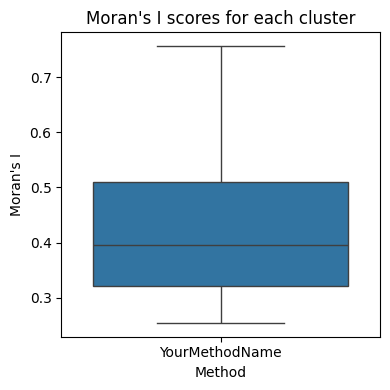

  cluster   moran_I          method
0       0  0.346486  YourMethodName
1       1  0.322535  YourMethodName
2       2  0.534473  YourMethodName
3       3  0.313182  YourMethodName
4       4  0.443193  YourMethodName
5       5  0.254079  YourMethodName
6       6  0.500781  YourMethodName
7       7  0.756640  YourMethodName


In [ ]:
import squidpy as sq
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_morans_I_per_method(labels, spatial_coords, method_name="MethodA"):
    adata = sc.AnnData(X=np.zeros((len(labels), 1)))
    adata.obs["cluster_label"] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    moran_scores = []
    unique_labels = np.unique(labels)

    for label in unique_labels:
        binary_vector = (labels == label).astype(int)
        adata.obs["tmp_binary"] = binary_vector

        sq.gr.spatial_autocorr(adata, mode="moran", genes="tmp_binary", attr="obs")
        I_score = adata.uns["moranI"].loc["tmp_binary", "I"]
        moran_scores.append({
            "cluster": str(label),
            "moran_I": I_score,
            "method": method_name
        })

    df_moran = pd.DataFrame(moran_scores)

    plt.figure(figsize=(4, 4))
    sns.boxplot(data=df_moran, x="method", y="moran_I")
    plt.title("Moran's I scores for each cluster")
    plt.ylabel("Moran's I")
    plt.xlabel("Method")
    plt.tight_layout()
    plt.show()

    return df_moran

morans_I_df = compute_morans_I_per_method(cluster_labels, coords, method_name="YourMethodName")
print(morans_I_df)
